# Defining the subevent matching algorithm

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks")
from loading_utils import load_root_file, load_hepmc_event

In [80]:
def load_and_merge_particles(edm_input_file: str, particles_root_file: str, event_id: int = 0, ignore_variable_columns: bool = False):
    """Load EDM4hep event and digi particles, then merge on phase-space columns.

    Returns (event, merged_particles DataFrame).
    """
    event = EDM4hepEvent(edm_input_file, event_index=event_id)
    particles = event.get_particles_df().reset_index().rename(columns={"index": "particle_id"})

    digi_particles = load_root_file(
        particles_root_file,
        event_id=event_id,
        ignore_variable_columns=ignore_variable_columns,
    ).reset_index(drop=True)

    # Align dtypes for robust merging
    for col in ["vx", "vy", "vz", "px", "py", "pz"]:
        if col in particles.columns:
            particles[col] = particles[col].astype("float32")
        if col in digi_particles.columns:
            digi_particles[col] = digi_particles[col].astype("float32")

    merge_cols = ["vx", "vy", "vz", "px", "py", "pz"]
    right_cols = merge_cols + [c for c in ["vertex_primary"] if c in digi_particles.columns]

    merged_particles = pd.merge(
        particles,
        digi_particles[right_cols],
        on=merge_cols,
        how="inner",
    )

    return event, merged_particles


def plot_vertexwise_by_event(
    edm_input_file: str,
    particles_root_file: str,
    n_events: int,
    num_vertices: int = 10,
    figsize_per_event=(6, 6),
    ignore_variable_columns: bool = False,
):
    """Create one subplot per event with vertex-wise tracker/calo hit overlays.

    event_ids: iterable of integers
    """
    if n_events == 0:
        raise ValueError("event_ids must be non-empty")

    fig, axes = plt.subplots(1, n_events, figsize=(figsize_per_event[0] * n_events, figsize_per_event[1]), squeeze=False)
    axes = axes[0]

    colors = cm.rainbow(np.linspace(0, 1, num_vertices))
    legend_handles, legend_labels = None, None

    for ax, ev in zip(axes, range(n_events)):
        event, merged_particles = load_and_merge_particles(
            edm_input_file,
            particles_root_file,
            event_id=ev,
            ignore_variable_columns=ignore_variable_columns,
        )
        hits = event.get_tracker_hits_df()
        calo_hits = event.get_calo_contributions_df()

        for i in range(1, num_vertices + 1):
            selected_particles = merged_particles[merged_particles.vertex_primary == i] if "vertex_primary" in merged_particles.columns else merged_particles.iloc[0:0]
            if selected_particles.empty:
                continue

            selected_tracker_hits = hits[hits.particle_id.isin(selected_particles.particle_id)]
            selected_calo_hits = calo_hits[calo_hits.particle_id.isin(selected_particles.particle_id)]

            n_tracker_hits = len(selected_tracker_hits)
            n_calo_hits = len(selected_calo_hits)
            total_calo_energy = float(selected_calo_hits.energy.sum()) if not selected_calo_hits.empty else 0.0

            # Use color= instead of c= to avoid UserWarning about value-mapping
            trk = ax.scatter(selected_tracker_hits.x, selected_tracker_hits.y, color=colors[i - 1], s=5, label=f"V{i} trk ({n_tracker_hits})")
            cal = ax.scatter(selected_calo_hits.x, selected_calo_hits.y, color=colors[i - 1], s=selected_calo_hits.energy, alpha=0.7, label=f"V{i} calo ({n_calo_hits}, E={total_calo_energy:.1f})")

            if legend_handles is None:
                legend_handles, legend_labels = [trk, cal], [trk.get_label(), cal.get_label()]

        ax.set_title(f"Event {ev}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.grid(True, alpha=0.3)

    if legend_handles is not None:
        fig.legend(legend_handles, legend_labels, loc="upper right", bbox_to_anchor=(1.15, 1.0))
    plt.tight_layout()
    return fig, axes


Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/4/edm4hep.root...
  Loaded 732971 particles.
  Loaded 206627 tracker hits.
  Loaded 1065861 calo hits and 5047052 contributions.
Loading event 1 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/4/edm4hep.root...
  Loaded 848328 particles.
  Loaded 230129 tracker hits.
  Loaded 1199504 calo hits and 5815576 contributions.


AttributeError: 'NoneType' object has no attribute 'reset_index'

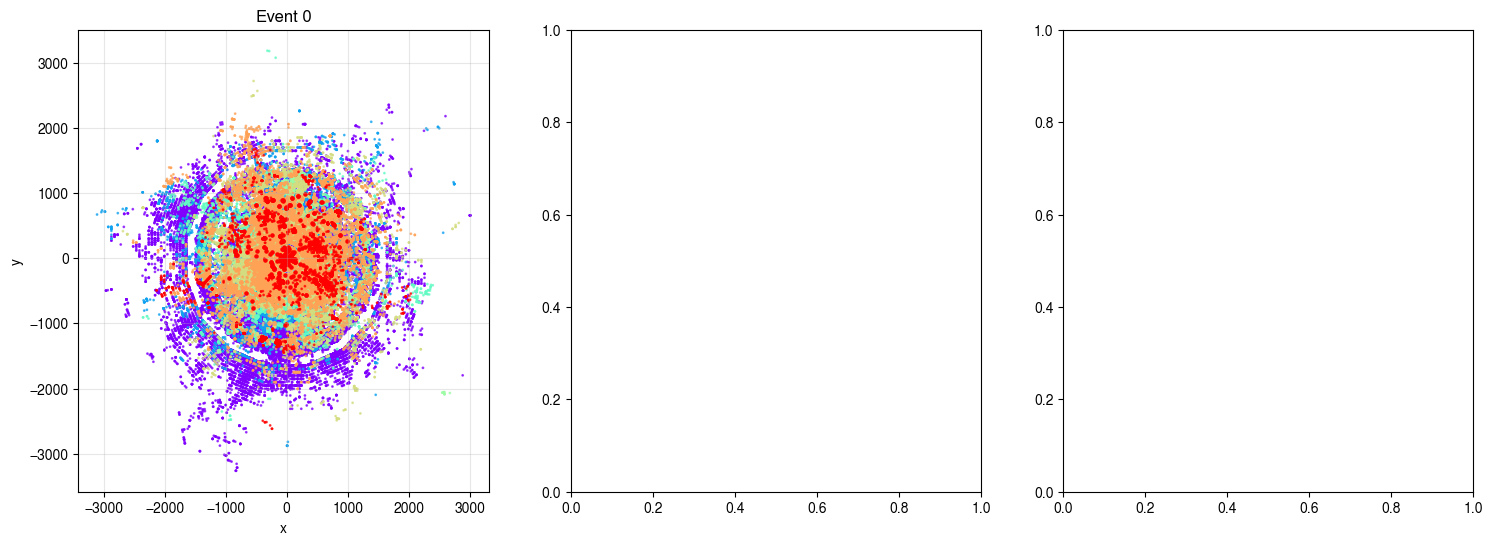

In [79]:
# Example usage:
fig, axes = plot_vertexwise_by_event(
    edm_input_file="/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/4/edm4hep.root",
    particles_root_file="/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/4/particles.root",
    n_events=3,
    num_vertices=10,
    figsize_per_event=(6, 6),
)
plt.show()


## Roadmap

1. Load an ACTS particles file
2. Examine primary vertices...


## Loading

In [2]:
edm_input_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/4/edm4hep.root"
event = EDM4hepEvent(edm_input_file, event_index=0)

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/4/edm4hep.root...
  Loaded 732971 particles.
  Loaded 206627 tracker hits.
  Loaded 1065861 calo hits and 5047052 contributions.


In [84]:
input_particles_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/4/particles.root"
digi_particles = load_root_file(input_particles_file, event_id=0, ignore_variable_columns=False)
digi_particles = digi_particles.reset_index(drop=True)

input_simhits_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/4/simhits.root"
simhits = load_root_file(input_simhits_file, event_id=0)
simhits = simhits.reset_index(drop=True)

input_digihits_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v6/runs/4/measurements.root"
digihits = load_root_file(input_digihits_file, event_id=0)
digihits = digihits.reset_index(drop=True)

In [43]:
hits = event.get_tracker_hits_df()
calo_hits = event.get_calo_contributions_df()

In [54]:
particles = event.get_particles_df()
particles = particles.reset_index().rename(columns={'index': 'particle_id'})

In [56]:
# Cast vx,vy,vz,time,px,py,pz to float32
particles = particles.astype({'vx': 'float32', 'vy': 'float32', 'vz': 'float32', 'time': 'float32', 'px': 'float32', 'py': 'float32', 'pz': 'float32'})
digi_particles = digi_particles.astype({'vx': 'float32', 'vy': 'float32', 'vz': 'float32', 'vt': 'float32', 'px': 'float32', 'py': 'float32', 'pz': 'float32'})

In [57]:
first_digi_particles = digi_particles[(digi_particles.vx == digi_particles.iloc[0].vx) & (digi_particles.vy == digi_particles.iloc[0].vy) & (digi_particles.vz == digi_particles.iloc[0].vz)][['vx', 'vy', 'vz', 'vt', 'px', 'py', 'pz']]

In [58]:
first_particles = particles[(particles.vx == particles.iloc[1].vx) & (particles.vy == particles.iloc[1].vy) & (particles.vz == particles.iloc[1].vz)][['vx', 'vy', 'vz', 'time', 'px', 'py', 'pz']]

In [59]:
first_digi_particles.sort_values(by='px')

,vx,vy,vz,vt,px,py,pz
112,-0.003381,0.001873,-26.240032,-1910.951172,-47.545452,13.273260,65.794434
684,-0.003381,0.001873,-26.240032,-1910.951172,-46.882828,13.121245,64.923676
0,-0.003381,0.001873,-26.240032,-1910.951172,-15.571697,-11.202291,1.977004
124,-0.003381,0.001873,-26.240032,-1910.951172,-14.408998,-10.517734,1.778430
90,-0.003381,0.001873,-26.240032,-1910.951172,-11.972124,16.433428,2.509892
...,...,...,...,...,...,...,...
75,-0.003381,0.001873,-26.240032,-1910.951172,3.132834,-0.066282,-8.470830
62,-0.003381,0.001873,-26.240032,-1910.951172,3.422888,-2.679017,-2.678127
17,-0.003381,0.001873,-26.240032,-1910.951172,29.350807,25.248127,266.198242
65,-0.003381,0.001873,-26.240032,-1910.951172,30.403559,-52.316521,-56.687664


In [60]:
first_particles.sort_values(by='px')

,vx,vy,vz,time,px,py,pz
193,-0.003381,0.001873,-26.240032,-6.374247,-65.492180,22.597702,90.474754
194,-0.003381,0.001873,-26.240032,-6.374247,-52.643124,14.706514,72.316902
197,-0.003381,0.001873,-26.240032,-6.374247,-50.565140,14.240724,69.499199
196,-0.003381,0.001873,-26.240032,-6.374247,-50.565140,14.240724,69.499199
221,-0.003381,0.001873,-26.240032,-6.374247,-47.545452,13.273260,65.794434
...,...,...,...,...,...,...,...
337,-0.003381,0.001873,-26.240032,-6.374247,41.901112,-71.958611,-78.753998
291,-0.003381,0.001873,-26.240032,-6.374247,46.760761,141.986069,209.787750
192,-0.003381,0.001873,-26.240032,-6.374247,47.085022,142.490524,210.409317
418,-0.003381,0.001873,-26.240032,-6.374247,58.732929,125.552521,207.277832


In [61]:
particles.columns

Index(['particle_id', 'pdg_id', 'generator_status', 'simulator_status',
       'charge', 'time', 'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz',
       'endpoint_x', 'endpoint_y', 'endpoint_z', 'parents_begin',
       'parents_end', 'daughters_begin', 'daughters_end', 'pt', 'p', 'eta',
       'phi', 'vr', 'endpoint_r', 'energy', 'kinetic_energy',
       'num_tracker_hits', 'num_calo_hits', 'created_in_simulation',
       'created_inside_tracker', 'ended_inside_tracker'],
      dtype='object')

In [62]:
digi_particles.columns

Index(['event_id', 'particle_id', 'particle_type', 'process', 'vx', 'vy', 'vz',
       'vt', 'px', 'py', 'pz', 'm', 'q', 'eta', 'phi', 'pt', 'p',
       'vertex_primary', 'vertex_secondary', 'particle', 'generation',
       'sub_particle', 'e_loss', 'total_x0', 'total_l0', 'number_of_hits',
       'outcome'],
      dtype='object')

In [63]:
# Match particles and digi_particles on left by vx,vy,vz,time,px,py,pz on right by vx,vy,vz,vt,px,py,pz
particles_match_columns = ['vx', 'vy', 'vz', 'px', 'py', 'pz']
digi_particles_match_columns = ['vx', 'vy', 'vz', 'px', 'py', 'pz']

merged_particles = pd.merge(particles, digi_particles[digi_particles_match_columns + ['vertex_primary']], left_on=particles_match_columns, right_on=digi_particles_match_columns, how='inner')

In [64]:
particles

,particle_id,pdg_id,generator_status,simulator_status,charge,time,mass,vx,vy,vz,...,phi,vr,endpoint_r,energy,kinetic_energy,num_tracker_hits,num_calo_hits,created_in_simulation,created_inside_tracker,ended_inside_tracker
0,0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.003865,7000.000000,6999.061730,0,0,False,False,False
1,1,21,61,0,0.000000,-6.374247,0.000000,-0.003381,0.001873,-26.240032,...,0.550128,0.003865,0.003865,955.905356,955.905356,0,0,False,False,False
2,2,2203,63,0,1.333333,-6.374247,0.771330,-0.003381,0.001873,-26.240032,...,0.000000,0.003865,0.003865,3913.633348,3912.862018,0,0,False,False,False
3,3,1,63,0,-0.333333,-6.374247,0.330000,-0.003381,0.001873,-26.240032,...,0.000000,0.003865,0.003865,2130.461315,2130.131315,0,0,False,False,False
4,4,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.003865,7000.000000,6999.061730,0,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732966,732966,11,0,1426063360,-1.000000,-1.991841,0.000511,-811.461731,-1022.001953,116.183754,...,-2.696229,1304.974377,1306.507595,0.012878,0.012367,0,19,True,False,False
732967,732967,-11,0,1426063360,1.000000,-1.991841,0.000511,-811.461731,-1022.001953,116.183754,...,-2.291621,1304.974377,1307.473103,0.008983,0.008472,0,1,True,False,False
732968,732968,11,0,1426063360,-1.000000,-2.128357,0.000511,-782.507080,-994.207947,113.132088,...,-2.124077,1265.214128,1266.441477,0.047988,0.047477,0,33,True,False,False
732969,732969,11,0,1426063360,-1.000000,-2.022501,0.000511,-798.600159,-1021.559448,113.283539,...,-2.119582,1296.667245,1305.238299,0.034463,0.033952,0,3,True,False,False


In [65]:
digi_particles

,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,vertex_primary,vertex_secondary,particle,generation,sub_particle,e_loss,total_x0,total_l0,number_of_hits,outcome
0,0,4503599627370496,423,0,-0.003381,0.001873,-26.240032,-1910.951172,-15.571697,-11.202291,...,1,0,0,0,0,17.381306,0.0,0.0,0,0
1,0,4503599627370497,113,0,-0.003381,0.001873,-26.240032,-1910.951172,-3.055261,-0.774980,...,1,0,0,0,1,0.000000,0.0,0.0,0,0
2,0,4503599627370498,213,0,-0.003381,0.001873,-26.240032,-1910.951172,-1.606188,-1.405872,...,1,0,0,0,2,0.000000,0.0,0.0,0,0
3,0,4503599627370499,221,0,-0.003381,0.001873,-26.240032,-1910.951172,-0.900303,-0.170033,...,1,0,0,0,3,0.000000,0.0,0.0,0,0
4,0,4503599627370500,-213,0,-0.003381,0.001873,-26.240032,-1910.951172,-1.429028,-0.366367,...,1,0,0,0,4,0.000000,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699082,0,905223525101535233,22,0,0.017181,-0.012158,15.711263,-3982.902832,0.003278,0.076824,...,201,0,0,1,1,0.000000,0.0,0.0,0,0
699083,0,905223525101600768,211,0,0.017181,-0.012158,15.711263,-3982.902832,-0.162776,0.675642,...,201,0,0,2,0,0.002837,0.0,0.0,0,0
699084,0,905223525101600769,-211,0,0.017181,-0.012158,15.711263,-3982.902832,0.145807,-0.173854,...,201,0,0,2,1,0.002390,0.0,0.0,0,0
699085,0,905224624613163010,22,0,0.017205,-0.012184,15.739954,-3982.874268,0.578590,-0.617564,...,201,1,0,1,2,0.000000,0.0,0.0,0,0


In [72]:
merged_particles.vertex_primary.unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [67]:
particles_with_hits = pd.concat([hits, calo_hits]).particle_id.unique()

In [68]:
particles_with_hits.shape

(586229,)

In [69]:
particle_present = np.isin(particles_with_hits, merged_particles.particle_id)

In [71]:
particle_present.sum()

np.int64(586229)

Vertex 1: 3156 tracker hits, 176857 calo hits, total calo energy: 17.12
Vertex 2: 0 tracker hits, 10 calo hits, total calo energy: 0.00
Vertex 3: 1713 tracker hits, 38263 calo hits, total calo energy: 4.26
Vertex 4: 0 tracker hits, 0 calo hits, total calo energy: 0.00


/tmp/ipykernel_2327346/1632067410.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(selected_tracker_hits.x, selected_tracker_hits.y, c=colors[i-1], s=5, label=f'Vertex {i} tracker ({n_tracker_hits} hits)')
/tmp/ipykernel_2327346/1632067410.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(selected_calo_hits.x, selected_calo_hits.y, c=colors[i-1], s=selected_calo_hits.energy, label=f'Vertex {i} 

Vertex 5: 1000 tracker hits, 19162 calo hits, total calo energy: 1.87
Vertex 6: 420 tracker hits, 9082 calo hits, total calo energy: 1.08
Vertex 7: 1381 tracker hits, 33699 calo hits, total calo energy: 3.39
Vertex 8: 1285 tracker hits, 32569 calo hits, total calo energy: 3.17
Vertex 9: 0 tracker hits, 0 calo hits, total calo energy: 0.00
Vertex 10: 271 tracker hits, 6095 calo hits, total calo energy: 0.66


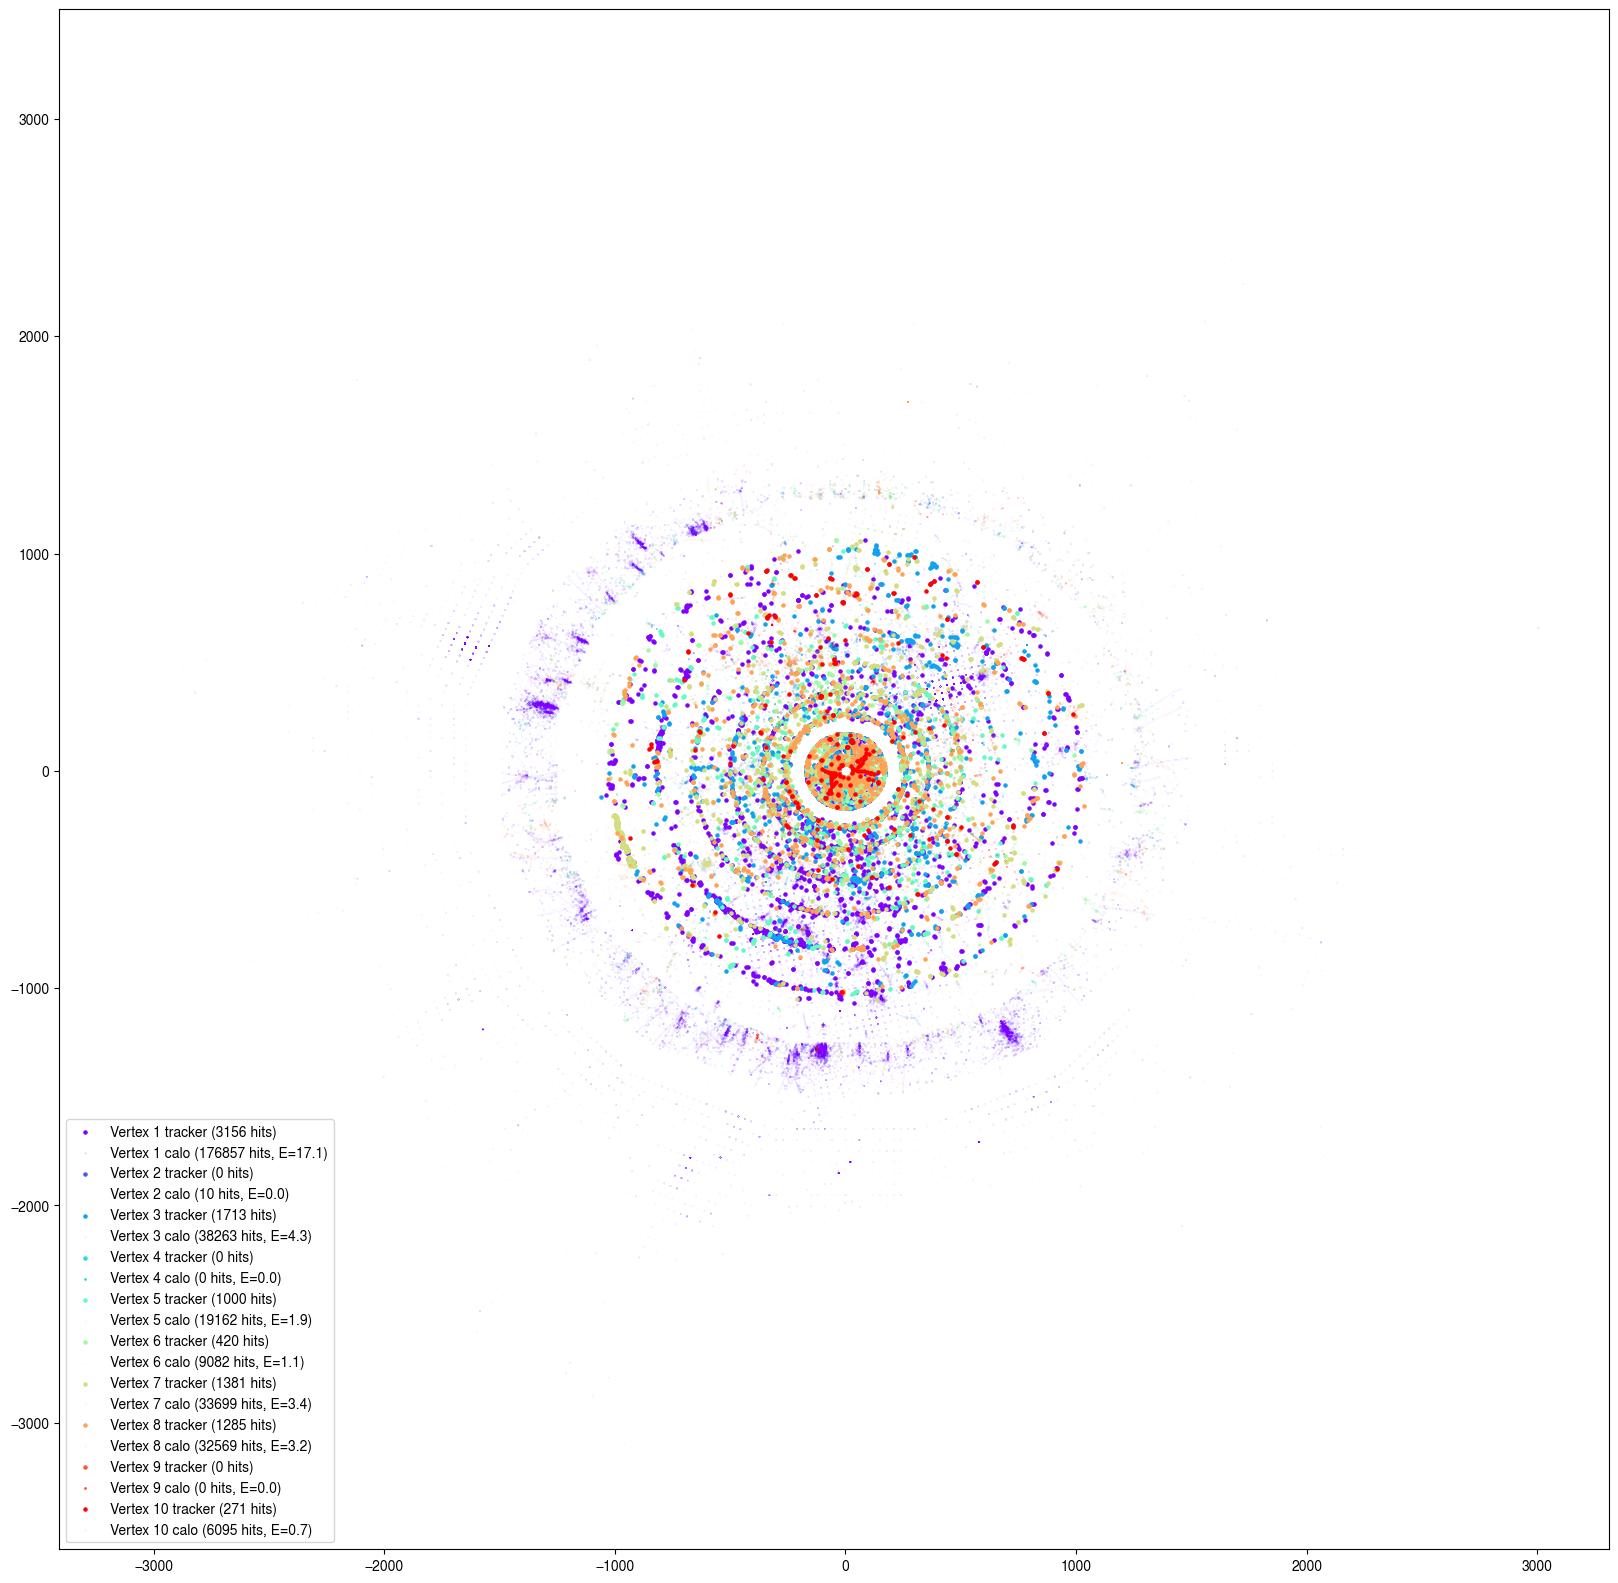

In [77]:
plt.figure(figsize=(20, 20))

num_vertices = 10

colors = cm.rainbow(np.linspace(0, 1, num_vertices))

for i in np.arange(1, num_vertices + 1):
    selected_particles = merged_particles[merged_particles.vertex_primary == i]
    selected_tracker_hits = hits[hits.particle_id.isin(selected_particles.particle_id)]
    selected_calo_hits = calo_hits[calo_hits.particle_id.isin(selected_particles.particle_id)]

    # Calculate statistics
    n_tracker_hits = len(selected_tracker_hits)
    n_calo_hits = len(selected_calo_hits)
    total_calo_energy = selected_calo_hits.energy.sum()
    
    print(f"Vertex {i}: {n_tracker_hits} tracker hits, {n_calo_hits} calo hits, total calo energy: {total_calo_energy:.2f}")

    plt.scatter(selected_tracker_hits.x, selected_tracker_hits.y, c=colors[i-1], s=5, label=f'Vertex {i} tracker ({n_tracker_hits} hits)')
    plt.scatter(selected_calo_hits.x, selected_calo_hits.y, c=colors[i-1], s=selected_calo_hits.energy, label=f'Vertex {i} calo ({n_calo_hits} hits, E={total_calo_energy:.1f})')

plt.legend()
plt.show()


## Merging Parents to Particles

In [2]:
edm_input_file = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root"
event = EDM4hepEvent(edm_input_file, event_index=0)
particles = event.get_particles_df()
particles = particles.reset_index().rename(columns={'index': 'particle_id'})

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0/edm4hep.root...
  Loaded 880327 particles.
  Loaded 240622 tracker hits.
  Loaded 1243953 calo hits and 6038426 contributions.


In [3]:
parents = event.get_parents_df()

In [4]:
parents

,particle_id,collectionID
0,0,2714477136
1,0,2714477136
2,0,2714477136
3,0,2714477136
4,5,2714477136
...,...,...
1042284,880316,2714477136
1042285,880276,2714477136
1042286,880276,2714477136
1042287,880276,2714477136


In [7]:
particles.parents_begin

0               0
1               0
2               1
3               2
4               3
           ...   
880322    1042284
880323    1042285
880324    1042286
880325    1042287
880326    1042288
Name: parents_begin, Length: 880327, dtype: int64